# **Bloque A): Exploracion de libreria y extracción de Datos**

Esta sección inicial establece la conexión con la API abierta de StatsBomb a través de su librería oficial. El código realiza una exploración de las competiciones disponibles para aislar los identificadores únicos de la Copa del Mundo de la FIFA 2022 (competition_id: 43, season_id: 106). Una vez localizado el torneo, se extrae el listado completo de los 64 partidos disputados. Mediante un bucle iterativo (for), el algoritmo descarga de forma secuencial el registro de eventos atómicos de cada encuentro y los unifica mediante una concatenación eficiente en un único objeto global: df_mundial_2022,con esto logramos transforma un origen de datos remoto y fragmentado por partidos en una base de datos centralizada de más de 234,000 filas y 114 columnas. Cada fila representa la mínima unidad de acción en el campo (un pase, un quite, un remate, etc.), permitiendo entender como se registran y ordenan los datos en esta libreria paara decidir el uso que se le dara a los datos.

In [1]:
pip install statsbombpy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00


In [2]:
from statsbombpy import sb
import pandas as pd

# 1. Llamamos a la base de datos "madre" que engloba todo
competiciones = sb.competitions()

# 2. Analizamos su composición: ¿Cuántas temporadas hay por cada competición?
# Agrupamos por nombre del torneo y contamos cuántas ediciones tienen
resumen_base = competiciones.groupby('competition_name')['season_name'].count().sort_values(ascending=False).reset_index()
resumen_base.columns = ['Competición', 'Cantidad de Temporadas Disponibles']

# 3. Visualizamos el Top 10 de competiciones más grandes en el Open Data
print("=== LAS COMPETICIONES CON MÁS DATOS EN STATSBOMB ===")
print(resumen_base.head(10).to_string(index=False))
print("=" * 52)

# 4. Mostramos cómo se compone el flujo de trabajo con un ejemplo
print("\n=== CÓMO SE COMPONE LA ESTRUCTURA (EL ÁRBOL) ===")
print("Nivel 1: sb.competitions()  -> Ejemplo: FIFA World Cup (ID: 43)")
print("         ↳ Nivel 2: sb.matches(43, 106)  -> Ejemplo: 64 Partidos del Mundial 2022")
print("                    ↳ Nivel 3: sb.events(3869685) -> Ejemplo: 3,000+ eventos de la Final Argentina vs Francia")

=== LAS COMPETICIONES CON MÁS DATOS EN STATSBOMB ===
            Competición  Cantidad de Temporadas Disponibles
       Champions League                                  18
                La Liga                                  18
         FIFA World Cup                                   8
FA Women's Super League                                   4
                Ligue 1                                   3
           Copa del Rey                                   3
          1. Bundesliga                                   2
       Liga Profesional                                   2
      Women's World Cup                                   2
      UEFA Women's Euro                                   2

=== CÓMO SE COMPONE LA ESTRUCTURA (EL ÁRBOL) ===
Nivel 1: sb.competitions()  -> Ejemplo: FIFA World Cup (ID: 43)
         ↳ Nivel 2: sb.matches(43, 106)  -> Ejemplo: 64 Partidos del Mundial 2022
                    ↳ Nivel 3: sb.events(3869685) -> Ejemplo: 3,000+ eventos de la Final Ar

/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
from statsbombpy import sb
import pandas as pd

# 1. Obtener todas las competiciones disponibles
competiciones = sb.competitions()

# 2. Filtrar el DataFrame para buscar solo la "FIFA World Cup"
mundiales = competiciones[competiciones['competition_name'] == 'FIFA World Cup']

# 3. Seleccionar las columnas más importantes para no saturar la pantalla
columnas_relevantes = [
    'competition_id',
    'competition_name',
    'season_id',
    'season_name',
    'country_name',
    'match_updated'
]

# 4. Mostrar el resultado
print("Mundiales disponibles en StatsBomb Open Data:")
print("-" * 50)
print(mundiales[columnas_relevantes].to_string(index=False))

Mundiales disponibles en StatsBomb Open Data:
--------------------------------------------------
 competition_id competition_name  season_id season_name  country_name              match_updated
             43   FIFA World Cup        106        2022 International 2026-05-04T01:48:57.914346
             43   FIFA World Cup          3        2018 International 2026-05-15T15:48:12.789440
             43   FIFA World Cup         55        1990 International 2023-06-28T10:58:20.137929
             43   FIFA World Cup         54        1986 International 2026-05-04T01:30:23.212111
             43   FIFA World Cup         51        1974 International 2026-05-15T02:20:43.439689
             43   FIFA World Cup        272        1970 International 2026-05-04T02:09:10.916859
             43   FIFA World Cup        270        1962 International 2026-05-04T02:05:35.653887
             43   FIFA World Cup        269        1958 International 2026-05-04T02:02:41.853159


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [4]:
mundiales

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
30,43,106,International,FIFA World Cup,male,False,True,2022,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,2026-05-04T01:53:40.309717,2026-05-04T01:48:57.914346
31,43,3,International,FIFA World Cup,male,False,True,2018,2026-05-15T15:48:12.789440,2021-06-13T16:17:31.694,None,2026-05-15T15:48:12.789440
32,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
33,43,54,International,FIFA World Cup,male,False,True,1986,2026-05-04T01:30:23.212111,2021-06-13T16:17:31.694,None,2026-05-04T01:30:23.212111
34,43,51,International,FIFA World Cup,male,False,True,1974,2026-05-15T02:20:43.439689,2021-06-13T16:17:31.694,None,2026-05-15T02:20:43.439689
35,43,272,International,FIFA World Cup,male,False,True,1970,2026-05-04T02:09:10.916859,None,None,2026-05-04T02:09:10.916859
36,43,270,International,FIFA World Cup,male,False,True,1962,2026-05-04T02:05:35.653887,None,None,2026-05-04T02:05:35.653887
37,43,269,International,FIFA World Cup,male,False,True,1958,2026-05-04T02:02:41.853159,None,None,2026-05-04T02:02:41.853159


In [5]:
mundial_2022 = mundiales[mundiales['season_name'] == '2022']
print("Mundial 2022:")
print("-" * 50)
print(mundial_2022[columnas_relevantes].to_string(index=False))

Mundial 2022:
--------------------------------------------------
 competition_id competition_name  season_id season_name  country_name              match_updated
             43   FIFA World Cup        106        2022 International 2026-05-04T01:48:57.914346


In [6]:
from statsbombpy import sb
import pandas as pd

# 1. Traer la base madre de competiciones
competiciones = sb.competitions()

# 2. Definir el Mundial y el año que queremos analizar
competicion_buscada = 'FIFA World Cup'
ano_buscado = '2022'

# 3. Filtrar de forma automática para obtener las IDs correctas
filtro = (competiciones['competition_name'] == competicion_buscada) & (competiciones['season_name'] == ano_buscado)
mundial_especifico = competiciones[filtro]

# Verificar si encontramos la edición solicitada
if not mundial_especifico.empty:
    # Extraemos los dos números clave (ID de competición e ID de temporada)
    comp_id = int(mundial_especifico['competition_id'].values[0])
    season_id = int(mundial_especifico['season_id'].values[0])

    print(f"=== Conectando a la API para el Mundial {ano_buscado} (IDs: {comp_id}, {season_id}) ===")

    # 4. Descargar TODOS los partidos de ese mundial usando sus IDs
    partidos = sb.matches(competition_id=comp_id, season_id=season_id)

    # 5. Seleccionar y ordenar las columnas esenciales para analizar la lista
    columnas_partido = [
        'match_id',          # ID clave para el siguiente paso (los eventos)
        'match_date',        # Fecha del partido
        'kick_off',          # Hora de inicio
        'home_team',         # Equipo local
        'away_team',         # Equipo visitante
        'home_score',        # Goles local
        'away_score',        # Goles visitante
        'competition_stage'  # Fase (Fase de grupos, Octavos, Final, etc.)
    ]

    # Ordenar los partidos por fecha para tener un orden cronológico lógico
    partidos_ordenados = partidos[columnas_partido].sort_values(by='match_date')

    # Mostrar el resultado final
    print(f"\nSe encontraron {len(partidos_ordenados)} partidos en este Mundial:")
    print("-" * 80)
    print(partidos_ordenados.to_string(index=False))

else:
    print(f"No se encontraron datos para el Mundial en el año {ano_buscado}.")

=== Conectando a la API para el Mundial 2022 (IDs: 43, 106) ===


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(



Se encontraron 64 partidos en este Mundial:
--------------------------------------------------------------------------------
 match_id match_date     kick_off     home_team     away_team  home_score  away_score competition_stage
  3857286 2022-11-20 16:00:00.000         Qatar       Ecuador           0           2       Group Stage
  3857271 2022-11-21 13:00:00.000       England          Iran           6           2       Group Stage
  3857282 2022-11-21 19:00:00.000 United States         Wales           1           1       Group Stage
  3857285 2022-11-21 16:00:00.000       Senegal   Netherlands           0           2       Group Stage
  3857254 2022-11-22 13:00:00.000       Denmark       Tunisia           0           0       Group Stage
  3857300 2022-11-22 10:00:00.000     Argentina  Saudi Arabia           1           2       Group Stage
  3857279 2022-11-22 19:00:00.000        France     Australia           4           1       Group Stage
  3857265 2022-11-22 16:00:00.000        M

In [7]:
from statsbombpy import sb
import pandas as pd

# 1. Definir el ID del partido exacto (Ej: Final Argentina vs Francia 2022)
id_partido = 3869685

print(f"Descargando eventos para el partido ID: {id_partido}...")

# 2. Extraer todos los eventos
eventos = sb.events(match_id=id_partido)

# 3. Entender el volumen de datos
filas, columnas = eventos.shape
print("-" * 60)
print(f"¡Descarga completa! El partido tiene {filas} eventos registrados.")
print(f"StatsBomb proporciona {columnas} variables distintas para analizar.")
print("-" * 60)

# 4. Aislar un tipo de evento: Los Tiros (Shots)
tiros = eventos[eventos['type'] == 'Shot']

# 5. Seleccionar columnas clave para ver quién pateó y si fue gol
columnas_tiros = [
    'minute',              # Minuto del partido
    'player',              # Jugador que patea
    'team',                # Equipo
    'shot_outcome',        # Resultado (Goal, Saved, Off T, etc.)
    'shot_statsbomb_xg'    # Goles Esperados (xG): probabilidad de que sea gol
]

print("\nPrimeros 5 tiros del partido:")
print(tiros[columnas_tiros].head().to_string(index=False))

Descargando eventos para el partido ID: 3869685...


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


------------------------------------------------------------
¡Descarga completa! El partido tiene 4407 eventos registrados.
StatsBomb proporciona 94 variables distintas para analizar.
------------------------------------------------------------

Primeros 5 tiros del partido:
 minute                          player      team shot_outcome  shot_statsbomb_xg
      4             Alexis Mac Allister Argentina        Saved           0.024542
      7          Rodrigo Javier De Paul Argentina      Blocked           0.062813
     16 Ángel Fabián Di María Hernández Argentina        Off T           0.106801
     22  Lionel Andrés Messi Cuccittini Argentina         Goal           0.783500
     31             Alexis Mac Allister Argentina      Wayward           0.010578


In [8]:
from statsbombpy import sb
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Para ocultar los avisos de la API sin credenciales

# 1. Obtener los IDs de los partidos del Mundial 2022 (Competición 43, Temporada 106)
partidos_2022 = sb.matches(competition_id=43, season_id=106)
lista_ids_partidos = partidos_2022['match_id'].tolist()

print(f"Se encontraron {len(lista_ids_partidos)} partidos. Iniciando descarga de eventos...")
print("Esto tomará un momento. Preparando un mate virtual... 🧉\n")

# 2. Descargar y consolidar todos los eventos de los 64 partidos
lista_eventos = []
for i, match_id in enumerate(lista_ids_partidos, 1):
    eventos_partido = sb.events(match_id=match_id)
    lista_eventos.append(eventos_partido)
    if i % 10 == 0:
        print(f"Descargados {i}/64 partidos...")

# Unir todos los DataFrames en una sola gran base de datos
df_mundial_2022 = pd.concat(lista_eventos, ignore_index=True)

# 3. Mostrar la estructura de la base de datos resultante
print("\n" + "="*50)
print("¡DESCARGA COMPLETADA!")
print(f"Total de acciones registradas (Filas): {df_mundial_2022.shape[0]:,}")
print(f"Total de variables disponibles (Columnas): {df_mundial_2022.shape[1]}")
print("="*50 + "\n")

# 4. Mostrar todas las variables disponibles ordenadas alfabéticamente
variables_disponibles = sorted(df_mundial_2022.columns.tolist())
print("--- DICCIONARIO DE VARIABLES (ORDEN ALFABÉTICO) ---")

# Imprimir en 3 columnas
for i in range(0, len(variables_disponibles), 3):
    fila = variables_disponibles[i:i+3]
    print("{:<35} {:<35} {:<35}".format(*fila + [""] * (3 - len(fila))))

Se encontraron 64 partidos. Iniciando descarga de eventos...
Esto tomará un momento. Preparando un mate virtual... 🧉

Descargados 10/64 partidos...
Descargados 20/64 partidos...
Descargados 30/64 partidos...
Descargados 40/64 partidos...
Descargados 50/64 partidos...
Descargados 60/64 partidos...

¡DESCARGA COMPLETADA!
Total de acciones registradas (Filas): 234,637
Total de variables disponibles (Columnas): 114

--- DICCIONARIO DE VARIABLES (ORDEN ALFABÉTICO) ---
50_50                               bad_behaviour_card                  ball_receipt_outcome               
ball_recovery_offensive             ball_recovery_recovery_failure      block_deflection                   
block_offensive                     block_save_block                    carry_end_location                 
clearance_aerial_won                clearance_body_part                 clearance_head                     
clearance_left_foot                 clearance_other                     clearance_right_foot        

# **Bloque B: Análisis Exploratorio de Datos (EDA) y Segmentación de variables por Familias Tácticas**

Ante la alta dimensionalidad del dataset (114 variables), este bloque aplica un criterio de filtrado y ordenamiento basado en el conocimiento del dominio (fútbol y analítica deportiva). En lugar de analizar la matriz a ciegas, el código segmenta las columnas en "familias tácticas" o dimensiones conceptuales: variables base/temporales, contexto espacial bajo presión, pases, tiros, conducciones y acciones defensivas. Permite identificar la estructura y la relevancia de cada variable dentro de su respectivo rol del juego antes de someterlas a transformaciones matemáticas directas apra ejecutar la ingenieria de variables

In [9]:
# Bloque 1: Base y Tiempo
cols_base = ['match_id', 'minute', 'second', 'duration', 'team', 'player', 'position', 'type']

print("--- 1. VARIABLES BASE Y TIEMPO ---")
# Mostramos las primeras 10 acciones generales
print(df_mundial_2022[cols_base].head(30).to_string(index=False))

--- 1. VARIABLES BASE Y TIEMPO ---
 match_id  minute  second  duration    team             player                  position        type
  3857276       0       0  0.000000  Canada                NaN                       NaN Starting XI
  3857276       0       0  0.000000 Morocco                NaN                       NaN Starting XI
  3857276       0       0  0.000000 Morocco                NaN                       NaN  Half Start
  3857276       0       0  0.000000  Canada                NaN                       NaN  Half Start
  3857276      45       0  0.000000 Morocco                NaN                       NaN  Half Start
  3857276      45       0  0.000000  Canada                NaN                       NaN  Half Start
  3857276       0       0  0.834690 Morocco  Youssef En-Nesyri            Center Forward        Pass
  3857276       0       2  1.470920 Morocco     Sofyan Amrabat Center Defensive Midfield        Pass
  3857276       0       5  2.262904 Morocco       Nayef 

In [10]:
# Bloque 2: Espacial y Contexto Táctico
cols_contexto = ['player', 'type', 'location', 'play_pattern', 'under_pressure', 'counterpress']

print("\n--- 2. CONTEXTO TÁCTICO (ACCIONES BAJO PRESIÓN) ---")
# Filtramos acciones donde el jugador estaba bajo presión
filtro_presion = df_mundial_2022['under_pressure'] == True
print(df_mundial_2022.loc[filtro_presion, cols_contexto].head(10).to_string(index=False))


--- 2. CONTEXTO TÁCTICO (ACCIONES BAJO PRESIÓN) ---
                 player type     location  play_pattern under_pressure counterpress
      Youssef En-Nesyri Pass [75.2, 34.4]  Regular Play           True          NaN
         Sofyan Amrabat Pass [56.5, 34.9]  Regular Play           True          NaN
   David Junior Hoilett Pass [69.3, 13.7]  Regular Play           True          NaN
      Abdelhamid Sabiri Pass [52.2, 20.0]  Regular Play           True          NaN
      Alistair Johnston Pass [34.0, 77.3] From Throw In           True          NaN
   David Junior Hoilett Pass [45.6, 28.6] From Throw In           True          NaN
      Mark Anthony Kaye Pass [47.8, 46.8] From Throw In           True          NaN
Steven de Sousa Vitoria Pass [31.5, 57.5] From Throw In           True          NaN
           Kamal Miller Pass [38.1, 14.4] From Kick Off           True          NaN
Steven de Sousa Vitoria Pass [28.1, 47.8] From Kick Off           True          NaN


In [11]:
# Bloque 3: Pases
cols_pases = [
    'player', 'pass_outcome', 'pass_end_location', 'pass_length',
    'pass_angle', 'pass_height', 'pass_cross', 'pass_through_ball',
    'pass_shot_assist'
]

print("\n--- 3. FAMILIA DE PASES ---")
filtro_pases = df_mundial_2022['type'] == 'Pass'
print(df_mundial_2022.loc[filtro_pases, cols_pases].head(10).to_string(index=False))


--- 3. FAMILIA DE PASES ---
            player pass_outcome pass_end_location  pass_length  pass_angle pass_height pass_cross pass_through_ball pass_shot_assist
 Youssef En-Nesyri          NaN      [48.5, 41.3]    12.557467    3.045886 Ground Pass        NaN               NaN              NaN
    Sofyan Amrabat          NaN      [30.5, 59.0]    24.344608    2.396870 Ground Pass        NaN               NaN              NaN
      Nayef Aguerd          NaN      [29.8, 26.9]    32.118843   -1.605051 Ground Pass        NaN               NaN              NaN
      Romain Saïss          NaN      [24.8, 58.4]    32.930990    1.781890 Ground Pass        NaN               NaN              NaN
      Nayef Aguerd          NaN      [34.7, 78.0]    20.077100    1.171791 Ground Pass        NaN               NaN              NaN
Achraf Hakimi Mouh          NaN      [36.8, 73.0]     7.602631   -0.953605 Ground Pass        NaN               NaN              NaN
    Sofyan Amrabat          NaN      [43

In [12]:
# Bloque 4: Tiros
cols_tiros = [
    'player', 'shot_statsbomb_xg', 'shot_outcome', 'shot_end_location',
    'shot_first_time', 'shot_one_on_one', 'shot_open_goal'
]

print("\n--- 4. FAMILIA DE TIROS ---")
filtro_tiros = df_mundial_2022['type'] == 'Shot'
print(df_mundial_2022.loc[filtro_tiros, cols_tiros].head(10).to_string(index=False))


--- 4. FAMILIA DE TIROS ---
           player  shot_statsbomb_xg shot_outcome  shot_end_location shot_first_time shot_one_on_one shot_open_goal
Mark Anthony Kaye           0.038882      Blocked      [104.1, 39.4]            True             NaN            NaN
     Hakim Ziyech           0.024477         Goal [120.0, 43.3, 1.4]            True             NaN            NaN
Abdelhamid Sabiri           0.022070      Blocked       [96.6, 38.4]             NaN             NaN            NaN
   Sofiane Boufal           0.061586      Wayward       [113.7, 0.1]             NaN             NaN            NaN
   Tajon Buchanan           0.279145        Off T [120.0, 27.3, 0.2]            True             NaN            NaN
     Hakim Ziyech           0.022624        Off T [120.0, 27.8, 7.1]             NaN             NaN            NaN
Youssef En-Nesyri           0.104058         Goal [120.0, 42.6, 0.2]             NaN            True            NaN
Abdelhamid Sabiri           0.097118      B

In [13]:
# Bloque 5: Conducción y Regates
cols_conduccion = [
    'player', 'type', 'carry_end_location', 'dribble_outcome',
    'dribble_nutmeg', 'ball_receipt_outcome'
]

print("\n--- 5. CONDUCCIÓN Y REGATES ---")
tipos_movimiento = ['Carry', 'Dribble', 'Ball Receipt*']
filtro_movimiento = df_mundial_2022['type'].isin(tipos_movimiento)
print(df_mundial_2022.loc[filtro_movimiento, cols_conduccion].head(10).to_string(index=False))


--- 5. CONDUCCIÓN Y REGATES ---
            player          type carry_end_location dribble_outcome dribble_nutmeg ball_receipt_outcome
    Sofyan Amrabat Ball Receipt*                NaN             NaN            NaN                  NaN
      Nayef Aguerd Ball Receipt*                NaN             NaN            NaN                  NaN
      Romain Saïss Ball Receipt*                NaN             NaN            NaN                  NaN
      Nayef Aguerd Ball Receipt*                NaN             NaN            NaN                  NaN
Achraf Hakimi Mouh Ball Receipt*                NaN             NaN            NaN                  NaN
    Sofyan Amrabat Ball Receipt*                NaN             NaN            NaN                  NaN
      Hakim Ziyech Ball Receipt*                NaN             NaN            NaN                  NaN
Achraf Hakimi Mouh Ball Receipt*                NaN             NaN            NaN                  NaN
      Nayef Aguerd Ball Receipt

In [14]:
# Bloque 6: Defensa y Recuperación
cols_defensa = [
    'player', 'type', 'duel_outcome', 'duel_type',
    'interception_outcome', 'clearance_aerial_won'
]

print("\n--- 6. DEFENSA Y RECUPERACIÓN ---")
tipos_defensivos = ['Duel', 'Interception', 'Clearance', 'Block', 'Ball Recovery', '50/50']
filtro_defensa = df_mundial_2022['type'].isin(tipos_defensivos)
print(df_mundial_2022.loc[filtro_defensa, cols_defensa].head(10).to_string(index=False))


--- 6. DEFENSA Y RECUPERACIÓN ---
            player type    duel_outcome   duel_type interception_outcome clearance_aerial_won
 Youssef En-Nesyri Duel             NaN Aerial Lost                  NaN                  NaN
    Sofiane Boufal Duel             NaN Aerial Lost                  NaN                  NaN
 Noussair Mazraoui Duel             NaN Aerial Lost                  NaN                  NaN
   Alphonso Davies Duel             NaN Aerial Lost                  NaN                  NaN
    Sofiane Boufal Duel        Lost Out      Tackle                  NaN                  NaN
Achraf Hakimi Mouh Duel        Lost Out      Tackle                  NaN                  NaN
 Alistair Johnston Duel             Won      Tackle                  NaN                  NaN
      Hakim Ziyech Duel    Lost In Play      Tackle                  NaN                  NaN
    Sofyan Amrabat Duel Success In Play      Tackle                  NaN                  NaN
      Nayef Aguerd Duel  

In [15]:
# Bloque 7: Infracciones y Faltas
cols_faltas = [
    'player', 'type', 'foul_committed_type', 'foul_won_advantage',
    'foul_committed_card', 'bad_behaviour_card'
]

print("\n--- 7. INFRACCIONES Y FALTAS ---")
tipos_infraccion = ['Foul Committed', 'Foul Won', 'Bad Behaviour']
filtro_infraccion = df_mundial_2022['type'].isin(tipos_infraccion)
print(df_mundial_2022.loc[filtro_infraccion, cols_faltas].head(10).to_string(index=False))


--- 7. INFRACCIONES Y FALTAS ---
                 player           type foul_committed_type foul_won_advantage foul_committed_card bad_behaviour_card
        Jonathan Osorio Foul Committed                 NaN                NaN                 NaN                NaN
   David Junior Hoilett Foul Committed                 NaN                NaN         Yellow Card                NaN
             Cyle Larin Foul Committed                 NaN                NaN                 NaN                NaN
         Sofiane Boufal Foul Committed                 NaN                NaN                 NaN                NaN
        Jonathan Osorio Foul Committed                 NaN                NaN         Yellow Card                NaN
             Cyle Larin Foul Committed                 NaN                NaN                 NaN                NaN
      Mark Anthony Kaye Foul Committed                 NaN                NaN                 NaN                NaN
         Sofiane Boufal Foul C

In [16]:
# Bloque 8: Arquero y Cambios
cols_arquero_cambios = [
    'player', 'type', 'goalkeeper_type', 'goalkeeper_outcome',
    'substitution_outcome', 'substitution_replacement'
]

print("\n--- 8. ARQUERO Y CAMBIOS ---")
tipos_pausa = ['Goal Keeper', 'Substitution']
filtro_pausa = df_mundial_2022['type'].isin(tipos_pausa)
print(df_mundial_2022.loc[filtro_pausa, cols_arquero_cambios].head(10).to_string(index=False))


--- 8. ARQUERO Y CAMBIOS ---
        player        type goalkeeper_type goalkeeper_outcome substitution_outcome substitution_replacement
Yassine Bounou Goal Keeper      Shot Faced                NaN                  NaN                      NaN
  Milan Borjan Goal Keeper   Goal Conceded           No Touch                  NaN                      NaN
  Milan Borjan Goal Keeper      Shot Faced                NaN                  NaN                      NaN
  Milan Borjan Goal Keeper           Punch     In Play Danger                  NaN                      NaN
  Milan Borjan Goal Keeper      Shot Faced                NaN                  NaN                      NaN
Yassine Bounou Goal Keeper      Shot Faced                NaN                  NaN                      NaN
  Milan Borjan Goal Keeper      Shot Faced                NaN                  NaN                      NaN
  Milan Borjan Goal Keeper   Goal Conceded           No Touch                  NaN                      Na

# **Fase 1: Selección Definitiva de Base de Datos (Competencias Internacionales)**
Tras la comprension de la libreria (bloque A) y la exploración masiva de las familias de datos (bloque B), aqui se consolida el universo de análisis seleccionando exclusivamente los torneos de selecciones absolutas más importantes de los últimos ciclos: el Mundial (2022), la Eurocopa, la Copa América y la Copa Africana de Naciones. El algoritmo filtra la base de datos final para aislar los eventos de estas competiciones, permitiendo homogeneizar el análisis en el ecosistema del fútbol de selecciones.


In [ ]:
import pandas as pd
from statsbombpy import sb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
from google.colab import files
from sklearn.cluster import KMeans

In [17]:


# 1. Obtener catálogo completo
comps = sb.competitions()

# 2. Definir el rango de años
años_objetivo = [str(año) for año in range(2010, 2027)]

# 3. Filtro:
filtro_historico = comps[
    (comps['competition_gender'] == 'male') &
    (comps['season_name'].isin(años_objetivo)) &
    (~comps['competition_name'].str.contains('U20|U17|U23', case=False, na=False)) &
    (comps['competition_name'].str.contains('World Cup|Euro|Copa America|Nations League|Asian Cup|African Cup', case=False, na=False))
]

# 4. Resultados
print(f"=== COMPETICIONES DE SELECCIONES DETECTADAS ({len(filtro_historico)} registros) ===")
resultados = filtro_historico[['competition_name', 'season_name', 'competition_id', 'season_id']].drop_duplicates()
resultados = resultados.sort_values(by=['season_name', 'competition_name'], ascending=[False, True])

display(resultados)

=== COMPETICIONES DE SELECCIONES DETECTADAS (6 registros) ===


,competition_name,season_name,competition_id,season_id
21,Copa America,2024,223,282
73,UEFA Euro,2024,55,282
2,African Cup of Nations,2023,1267,107
30,FIFA World Cup,2022,43,106
74,UEFA Euro,2020,55,43
31,FIFA World Cup,2018,43,3


In [18]:
# 1. Definimos la lista exacta de las competiciones
data = {
    'competition_name': ['Copa America', 'UEFA Euro', 'African Cup of Nations', 'FIFA World Cup', 'UEFA Euro', 'FIFA World Cup'],
    'season_name': ['2024', '2024', '2023', '2022', '2020', '2018'],
    'competition_id': [223, 55, 1267, 43, 55, 43],
    'season_id': [282, 282, 107, 106, 43, 3]
}
df_objetivos = pd.DataFrame(data)

lista_eventos_multi = []

# 2. Bucle de descarga consolidada
for index, row in df_objetivos.iterrows():
    comp_id = row['competition_id']
    s_id = row['season_id']
    nombre = row['competition_name']
    temporada = row['season_name']

    print(f"--- Iniciando descarga: {nombre} ({temporada}) ---")

    try:
        # Obtener lista de partidos
        matches = sb.matches(competition_id=comp_id, season_id=s_id)
        match_ids = matches['match_id'].unique()

        print(f"Se encontraron {len(match_ids)} partidos.")

        for match_id in match_ids:
            try:
                # Descarga de eventos
                events = sb.events(match_id=match_id)
                events['competition_name'] = nombre
                events['season_name'] = temporada
                lista_eventos_multi.append(events)
            except Exception as e:
                print(f"  [!] Fallo en partido {match_id}: {e}")
                continue

    except Exception as e:
        print(f"  [X] Error fatal al procesar {nombre}: {e}")
        continue

# 3. Consolidación final
if lista_eventos_multi:
    df_consolidado = pd.concat(lista_eventos_multi, ignore_index=True)
    print(f"\n✅ Descarga completada con éxito.")
    print(f"Total de eventos consolidados: {len(df_consolidado):,}")

    # Verificación rápida
    print("\nEventos por competición:")
    print(df_consolidado.groupby(['competition_name', 'season_name']).size())
else:
    print("\n[!] No se pudieron recuperar eventos. Verifica tu conexión a StatsBomb.")

--- Iniciando descarga: Copa America (2024) ---
Se encontraron 32 partidos.
--- Iniciando descarga: UEFA Euro (2024) ---
Se encontraron 51 partidos.
--- Iniciando descarga: African Cup of Nations (2023) ---
Se encontraron 52 partidos.
--- Iniciando descarga: FIFA World Cup (2022) ---
Se encontraron 64 partidos.
--- Iniciando descarga: UEFA Euro (2020) ---
Se encontraron 51 partidos.
--- Iniciando descarga: FIFA World Cup (2018) ---
Se encontraron 64 partidos.

✅ Descarga completada con éxito.
Total de eventos consolidados: 1,106,277

Eventos por competición:
competition_name        season_name
African Cup of Nations  2023           162903
Copa America            2024           100324
FIFA World Cup          2018           227825
                        2022           234637
UEFA Euro               2020           192664
                        2024           187924
dtype: int64


# **Fase 2: Ingeniería de Variables y filtro de jugadores**

El código cambia la unidad de análisis: pasa de una matriz de eventos a una matriz de jugadores mediante un proceso de agregación (groupby('player')).
Para construir las variables de rendimiento, se aplican máscaras lógicas que cuantifican acciones específicas. Se realizan filtro de Exposición Mínima: Se calcula el tiempo total de juego de cada futbolista y se descarta a aquellos con menos de 270 minutos (equivalente a 3 partidos completos). Esto mitiga el sesgo y la alta varianza que introducen las muestras pequeñas (evitando que un jugador con pocos minutos muestre un 100% de efectividad artificial).

In [19]:
# 1. Filtrar eventos y crear mascaras para el dataset multi-torneo
df_players_multi = df_consolidado.dropna(subset=['player']).copy()

# Pases
df_players_multi['es_pase'] = df_players_multi['type'] == 'Pass'
df_players_multi['pase_exitoso'] = df_players_multi['es_pase'] & df_players_multi['pass_outcome'].isna()
df_players_multi['pase_bajo_presion'] = df_players_multi['es_pase'] & (df_players_multi['under_pressure'] == True)
df_players_multi['filtrado_exitoso'] = (df_players_multi['pass_through_ball'] == True) & df_players_multi['pass_outcome'].isna()

# Tiros
df_players_multi['es_tiro'] = df_players_multi['type'] == 'Shot'
df_players_multi['es_gol'] = df_players_multi['shot_outcome'] == 'Goal'
df_players_multi['xG'] = df_players_multi['shot_statsbomb_xg'].fillna(0)

# Defensa
df_players_multi['es_intercepcion'] = df_players_multi['type'] == 'Interception'
df_players_multi['es_recuperacion'] = df_players_multi['type'] == 'Ball Recovery'
df_players_multi['duelo_aereo_ganado'] = (df_players_multi['type'] == 'Duel') & (df_players_multi['duel_outcome'].isin(['Won', 'Success In Play']))
df_players_multi['duelo_aereo_total'] = (df_players_multi['type'] == 'Duel') & (df_players_multi['duel_type'].astype(str).str.contains('Aerial'))

# 2. Agregacion (Construccion del volumen bruto)
agrupado_multi = df_players_multi.groupby(['player', 'team']).agg(
    position=('position', lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A'),
    partidos_jugados=('match_id', 'nunique'),
    influencia_total=('id', 'count'),
    pases_totales=('es_pase', 'sum'),
    pases_exitosos_totales=('pase_exitoso', 'sum'),
    pases_presion_totales=('pase_bajo_presion', 'sum'),
    asistencias_tiro=('pass_shot_assist', 'sum'),
    tiros_totales=('es_tiro', 'sum'),
    goles_totales=('es_gol', 'sum'),
    xG_total=('xG', 'sum'),
    intercepciones_totales=('es_intercepcion', 'sum'),
    recuperaciones_totales=('es_recuperacion', 'sum'),
    duelos_aereos_ganados=('duelo_aereo_ganado', 'sum'),
    duelos_aereos_totales=('duelo_aereo_total', 'sum'),
    faltas_recibidas=('type', lambda x: (x == 'Foul Won').sum())
).reset_index()

# 3. Calculo de Minutos Totales
minutos_match = df_players_multi.groupby(['player', 'match_id'])['minute'].max().reset_index()
minutos_totales_multi = minutos_match.groupby('player')['minute'].sum().reset_index().rename(columns={'minute': 'minutos_jugados'})

perfiles_multi = pd.merge(agrupado_multi, minutos_totales_multi, on='player')

# Filtro de representatividad (270 min)
perfiles_multi = perfiles_multi[perfiles_multi['minutos_jugados'] >= 270].copy()

# 4. Estandarizacion P90 y Proporciones (Usando nombres compatibles con el Bloque Final)
perfiles_multi['xG P90'] = (perfiles_multi['xG_total'] / perfiles_multi['minutos_jugados']) * 90
perfiles_multi['Asistencias a Tiro P90'] = (perfiles_multi['asistencias_tiro'].astype(float) / perfiles_multi['minutos_jugados']) * 90
perfiles_multi['Intercepciones P90'] = (perfiles_multi['intercepciones_totales'] / perfiles_multi['minutos_jugados']) * 90
perfiles_multi['Recuperaciones P90'] = (perfiles_multi['recuperaciones_totales'] / perfiles_multi['minutos_jugados']) * 90
perfiles_multi['Influencia Global P90'] = (perfiles_multi['influencia_total'] / perfiles_multi['minutos_jugados']) * 90
perfiles_multi['Faltas Recibidas P90'] = (perfiles_multi['faltas_recibidas'] / perfiles_multi['minutos_jugados']) * 90

# Variables de proporcion
perfiles_multi['% Pases Bajo Presión'] = np.where(perfiles_multi['influencia_total'] > 0, perfiles_multi['pases_presion_totales'] / perfiles_multi['influencia_total'], 0)
perfiles_multi['xG por Tiro'] = np.where(perfiles_multi['tiros_totales'] > 0, perfiles_multi['xG_total'] / perfiles_multi['tiros_totales'], 0)
perfiles_multi['% Pases Exitosos'] = np.where(perfiles_multi['pases_totales'] > 0, perfiles_multi['pases_exitosos_totales'] / perfiles_multi['pases_totales'], 0)
perfiles_multi['% Duelos Aéreos'] = np.where(perfiles_multi['duelos_aereos_totales'] > 0, perfiles_multi['duelos_aereos_ganados'] / perfiles_multi['duelos_aereos_totales'], 0)

print(f"--- BALANCE DE LA MUESTRA ---")
print(f"Jugadores incluidos: {len(perfiles_multi)}")

--- BALANCE DE LA MUESTRA ---
Jugadores incluidos: 1288


### 📖 Diccionario de Datos Completo: Trazabilidad y Construcción de Variables

Este diccionario documenta la totalidad de las variables construidas en el pipeline de preprocesamiento, divididas en tres fases estadísticas: la identificación a nivel de evento, la agregación de volumen absoluto y, finalmente, la estandarización matemática.

#### Fase 1: Variables de Identificación (Máscaras a nivel de evento)
Estas variables se crean en el dataset crudo (`df_players_multi`) para etiquetar lógicamente (`True`/`False`) o cuantificar cada acción individual.

1. **`es_pase`**: Booleano. Indica si la acción registrada es un intento de pase.
2. **`pase_exitoso`**: Booleano. Indica si el pase no registró ningún error en la base de datos (llegó a destino).
3. **`pase_bajo_presion`**: Booleano. Cruza un evento de pase con la métrica contextual de asedio o presión defensiva rival.
4. **`filtrado_exitoso`**: Booleano. Identifica si la acción es un pase que rompe líneas (*through ball*) y fue completado con éxito.
5. **`es_tiro`**: Booleano. Indica si la acción es un intento de remate.
6. **`es_gol`**: Booleano. Indica si el resultado de la acción de remate culminó en gol.
7. **`xG` (Expected Goals)**: Numérico continuo. Probabilidad estadística (0 a 1) de que un remate sea gol según la posición y contexto. Se imputa como `0` si la acción no es un tiro.
8. **`es_intercepcion`**: Booleano. Acción de lectura y corte en una línea de pase rival.
9. **`es_recuperacion`**: Booleano. Obtención de la posesión tras un balón suelto (*Ball Recovery*).
10. **`duelo_aereo_ganado`**: Booleano. Disputa por alto que resulta en victoria o mantenimiento de la posesión.
11. **`duelo_aereo_total`**: Booleano. Identifica cualquier evento catalogado como disputa aérea, independientemente de su resultado.

#### Fase 2: Volúmenes Absolutos (Agregación por Jugador)
Estas variables representan el recuento total de acciones agrupadas por cada jugador a lo largo de los torneos (`agrupado_multi`).

12. **`partidos_jugados`**: Conteo de identificadores de partido únicos en los que el jugador registró actividad.
13. **`influencia_total`**: Volumen bruto total de intervenciones del jugador en el juego (suma de todas sus filas en la base de datos).
14. **`pases_totales`**: Cantidad absoluta de pases intentados.
15. **`pases_exitosos_totales`**: Cantidad absoluta de pases completados.
16. **`pases_presion_totales`**: Cantidad absoluta de pases ejecutados bajo presión.
17. **`asistencias_tiro`**: Cantidad de pases que derivaron directamente en el remate de un compañero (*Key Passes*).
18. **`tiros_totales`**: Cantidad total de remates intentados.
19. **`goles_totales`**: Sumatoria total de goles marcados.
20. **`xG_total`**: Acumulación total del peligro generado (suma de los xG de todos sus tiros).
21. **`intercepciones_totales`**: Cantidad absoluta de pases rivales interceptados.
22. **`recuperaciones_totales`**: Cantidad absoluta de balones recuperados.
23. **`duelos_aereos_ganados`**: Cantidad total de disputas aéreas victoriosas.
24. **`duelos_aereos_totales`**: Volumen total de disputas aéreas protagonizadas.
25. **`faltas_recibidas`**: Conteo absoluto de infracciones sufridas.
26. **`minutos_jugados`**: Suma del tiempo total de exposición del jugador (utilizado como denominador crítico y filtro de varianza).

#### Fase 3: Estandarización y Eficiencia (Matriz de Diseño SOM)
Estas variables transforman los volúmenes brutos en métricas comparables (Tasas P90) y razones matemáticas de eficiencia (`perfiles_multi`), conformando la matriz final que alimenta a los algoritmos de *Machine Learning*.

27. **`xG_P90`**: Calidad de las ocasiones de gol generadas proyectadas a 90 minutos de juego.
28. **`asistencias_tiro_P90`**: Tasa de pases para remate por partido completo.
29. **`intercepciones_P90`**: Tasa estandarizada de cortes defensivos por cada 90 minutos.
30. **`recuperaciones_P90`**: Frecuencia de recuperación de balones sueltos estandarizada por partido.
31. **`influencia_P90`**: Tasa que mide el nivel de participación y volumen de acciones del jugador por cada 90 minutos en cancha.
32. **`faltas_recibidas_P90`**: Capacidad para forzar infracciones del rival proyectada a un partido completo.
33. **`%_Pases_Presion`**: Razón de estrés táctico (Pases bajo presión / Influencia total). Mide qué porcentaje del juego del futbolista ocurre bajo acoso.
34. **`xG_por_Tiro`**: Razón de eficiencia de remate (xG Total / Tiros Totales). Evalúa la calidad promedio de las decisiones de disparo.
35. **`%_Pases_Exitosos`**: Razón de seguridad en distribución (Pases completados / Pases intentados).
36. **`%_Duelos_Aereos`**: Razón de dominancia física por aire (Duelos aéreos ganados / Duelos aéreos totales).

In [20]:
perfiles_multi.head()

,player,team,position,partidos_jugados,influencia_total,pases_totales,pases_exitosos_totales,pases_presion_totales,asistencias_tiro,tiros_totales,...,xG P90,Asistencias a Tiro P90,Intercepciones P90,Recuperaciones P90,Influencia Global P90,Faltas Recibidas P90,% Pases Bajo Presión,xG por Tiro,% Pases Exitosos,% Duelos Aéreos
0,Aaron Mooy,Australia,Left Center Midfield,7,1284,425,339,73,12,4,...,0.012857,1.653905,0.826953,7.029096,176.967841,0.275651,0.056854,0.023322,0.797647,1.600000
1,Aaron Ramsey,Wales,Left Center Midfield,7,1074,267,207,53,5,8,...,0.200252,0.707547,0.990566,5.094340,151.981132,1.981132,0.049348,0.176889,0.775281,0.727273
2,Aaron Tshibola,Congo DR,Right Defensive Midfield,6,266,70,61,5,2,1,...,0.127976,0.326679,0.490018,1.306715,43.448276,0.163339,0.018797,0.783500,0.871429,1.000000
4,Abdelhamid Sabiri,Morocco,Left Center Midfield,5,242,58,46,11,2,4,...,0.194796,0.429594,1.073986,0.644391,51.980907,0.644391,0.045455,0.226721,0.793103,1.000000
5,Abdelkarim Hassan Al Haj Fadlalla,Qatar,Left Center Back,3,524,158,125,21,True,6,...,0.089322,0.324910,0.974729,3.898917,170.252708,1.299639,0.040076,0.045819,0.791139,1.000000


In [21]:
len(perfiles_multi)

1288

### 📊 Matriz de Correlación: Dataset Consolidado

Ahora que tenemos una base de datos más robusta que incluye múltiples torneos internacionales, es fundamental verificar si las correlaciones entre nuestras 10 variables tácticas se mantienen consistentes. Esto nos asegura que el modelo SOM recibirá información coherente y no redundante.


MATRIZ DE CORRELACIÓN: Dataset Internacional (1288 jugadores)


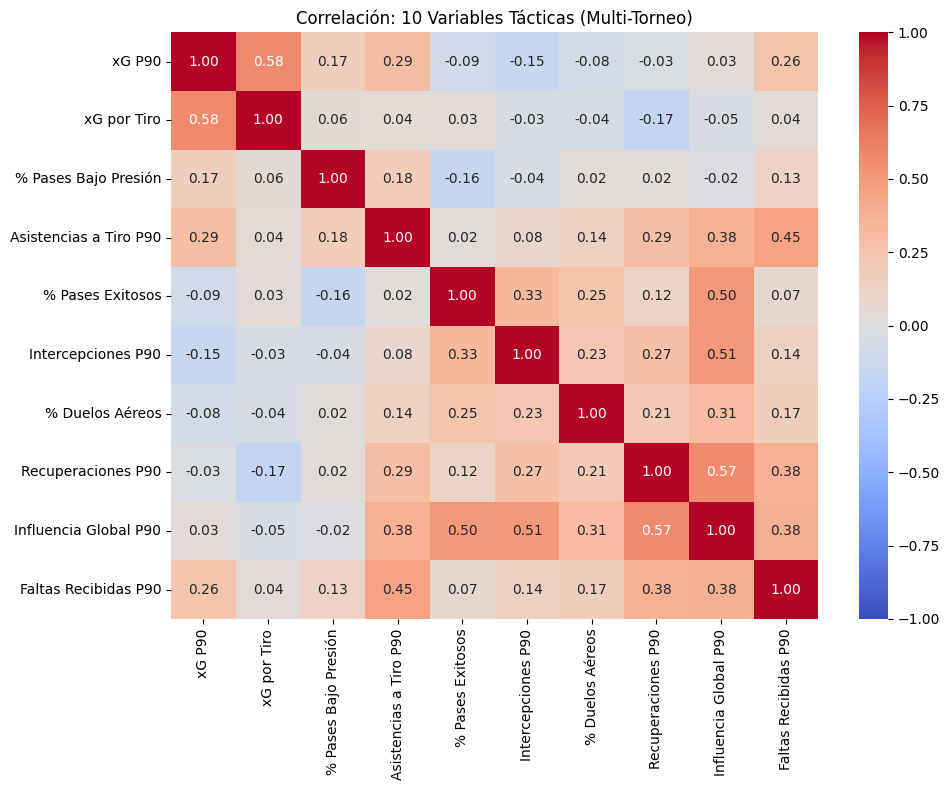

In [22]:
# 1. Definir las 10 variables tácticas finales para el SOM
feature_names = [
    'xG P90',
    'xG por Tiro',
    '% Pases Bajo Presión',
    'Asistencias a Tiro P90',
    '% Pases Exitosos',
    'Intercepciones P90',
    '% Duelos Aéreos',
    'Recuperaciones P90',
    'Influencia Global P90',
    'Faltas Recibidas P90'
]

# 2. Matriz de correlación para validación del nuevo dataset
print(f"\nMATRIZ DE CORRELACIÓN: Dataset Internacional ({len(perfiles_multi)} jugadores)")
print("="*70)
corr_matrix = perfiles_multi[feature_names].corr()

os.makedirs('SOM', exist_ok=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlación: 10 Variables Tácticas (Multi-Torneo)")
plt.tight_layout()
plt.savefig("SOM/correlacion_variables.png", dpi=300)
plt.show()

# 3. Preparación de la matriz X normalizada para el SOM
X_raw = perfiles_multi[feature_names].values.astype(float)
X_min, X_max = X_raw.min(axis=0), X_raw.max(axis=0)
X = (X_raw - X_min) / (X_max - X_min + 1e-8)
n_samples, n_features = X.shape
player_clusters_df = perfiles_multi.copy()

## 📖 Diccionario de Variables (Seleccionadas para el SOM)

Para el análisis táctico del Mundial 2022, hemos seleccionado estas 10 métricas clave normalizadas P90 o como porcentajes:

1. **xG P90**: Volumen de peligro generado por el jugador.
2. **xG por Tiro**: Calidad promedio de las decisiones de remate.
3. **% Pases Bajo Presión**: Capacidad de mantener la posesión en situaciones críticas.
4. **Asistencias a Tiro P90**: Frecuencia de creación de oportunidades para compañeros.
5. **% Pases Exitosos**: Efectividad general en la distribución.
6. **Intercepciones P90**: Capacidad de lectura defensiva y corte de juego.
7. **% Duelos Aéreos**: Dominancia física en balones divididos por alto.
8. **Recuperaciones P90**: Intensidad para recuperar la posesión del balón.
9. **Influencia Global P90**: Volumen total de intervenciones del jugador en el juego.
10. **Faltas Recibidas P90**: Capacidad para desequilibrar y forzar infracciones del rival.

### 🧬 Fase 3: Búsqueda de Hiperparámetros mediante Algoritmo Genético (AG)

**1. Fundamento Metodológico del Algoritmo Genético (AG)**
Para evitar la selección empírica o arbitraria de los hiperparámetros de la red neuronal, en esta fase se implementa exclusivamente un Algoritmo Genético (AG). Este motor de búsqueda metaheurístico explora el espacio de soluciones evaluando arquitecturas candidatas (cromosomas) compuestas por: `[Filas, Columnas, Sigma, Learning Rate]`.

Para garantizar una convergencia robusta y evitar el estancamiento en óptimos locales, el AG integra cuatro mecanismos avanzados:
* **Fitness Multiobjetivo Restringido:** Evalúa cada arquitectura calculando un promedio entre el Error de Cuantificación (precisión del ajuste) y el Error Topológico (coherencia espacial). Además, restringe el espacio de búsqueda penalizando configuraciones que se alejen de la regla heurística ($M \approx 5 \times \sqrt{N}$).
* **Torneos de Baja Presión Selectiva (k=2):** Protege la diversidad genética permitiendo que arquitecturas subóptimas, pero con genes valiosos, sobrevivan.
* **Cruce Uniforme y Mutación Gaussiana:** Permite la herencia independiente gen por gen y aplica ruido estadístico (distribución normal) para realizar ajustes finos en variables continuas como la tasa de aprendizaje.
* **Inyección Aleatoria (Alienígenas):** Reemplaza periódicamente a los peores individuos con configuraciones 100% aleatorias para forzar la exploración de nuevas zonas del espacio paramétrico.

**2. Evaluación de Aptitud (Entrenamiento Rápido)**
Dentro del ciclo evolutivo, el AG necesita saber qué tan bueno es cada cromosoma. Para medirlo, ejecuta un entrenamiento rápido de prueba (ej. 5000 iteraciones) sobre una versión temporal del modelo. Esto permite medir la "tendencia de convergencia" de cientos de configuraciones distintas en un tiempo computacional razonable, identificando qué arquitectura tiene el mayor potencial matemático.

**3. Objetivo y Salida de esta Fase**
El propósito único de este bloque es realizar la exploración algorítmica. **No se generará el modelo final aquí**. Una vez que el proceso evolutivo concluya, los hiperparámetros ganadores serán extraídos y almacenados. Estos valores óptimos serán utilizados posteriormente para inicializar el Mapa Autoorganizado (SOM) definitivo, cuyo entrenamiento profundo y análisis se detallarán en el siguiente bloque del código.

In [23]:

# ==================================================================================
# FUNCIONES DEL ALGORITMO GENÉTICO (AG) Y EVALUACIÓN SOM
# ==================================================================================

# LIMITES Y CONFIGURACION DEL ESPACIO DE BÚSQUEDA
# BOUNDS = [(Filas), (Columnas), (Sigma), (Learning Rate)]
BOUNDS = [(5, 20), (5, 20), (1.0, 10.0), (0.05, 0.9)]

def crear_individuo():
    """Crea un cromosoma aleatorio dentro de los límites permitidos."""
    return [
        random.randint(BOUNDS[0][0], BOUNDS[0][1]),
        random.randint(BOUNDS[1][0], BOUNDS[1][1]),
        random.uniform(BOUNDS[2][0], BOUNDS[2][1]),
        random.uniform(BOUNDS[3][0], BOUNDS[3][1])
    ]

def topological_error(weights, X_train):
    """
    Calcula el Error Topológico (TE) de forma eficiente.
    Para cada punto, busca los 2 BMUs más cercanos.
    Si no son vecinos inmediatos en la grilla (distancia Manhattan > 1), cuenta como error.
    """
    n_features = weights.shape[2]
    dists = np.sqrt(np.sum((weights.reshape(-1, n_features) - X_train[:, np.newaxis, :])**2, axis=2))

    bmu_indices = np.argsort(dists, axis=1)[:, :2]

    m, n = weights.shape[0], weights.shape[1]
    bmu1 = np.unravel_index(bmu_indices[:, 0], (m, n))
    bmu2 = np.unravel_index(bmu_indices[:, 1], (m, n))

    grid_dist = np.abs(bmu1[0] - bmu2[0]) + np.abs(bmu1[1] - bmu2[1])
    return np.mean(grid_dist > 1)

def train_som_fast(data, m, n, n_iter, alpha0, sigma0):
    """Entrenamiento rápido del SOM para evaluar el fitness del cromosoma."""
    n_features = data.shape[1]
    weights = np.random.rand(m, n, n_features)
    grid_pos = np.array([[(i, j) for j in range(n)] for i in range(m)], dtype=float)
    lam = n_iter / np.log(sigma0 + 1e-8)

    for t in range(n_iter):
        x = data[np.random.randint(len(data))]
        dists_to_x = np.sum((weights - x)**2, axis=2)
        bmu_idx = np.unravel_index(np.argmin(dists_to_x), (m, n))

        a_t = alpha0 * np.exp(-t / lam)
        s_t = sigma0 * np.exp(-t / lam)

        dist_grid_sq = np.sum((grid_pos - np.array(bmu_idx))**2, axis=2)
        h = np.exp(-dist_grid_sq / (2.0 * s_t**2 + 1e-8))
        weights += a_t * h[:, :, np.newaxis] * (x - weights)

    qe = np.mean([np.min(np.sum((weights - d)**2, axis=2)) for d in data])
    return weights, qe

def calcular_fitness_avanzado(cromosoma, datos, limite_inferior, limite_superior):
    """
    Función de evaluación (Fitness Multiobjetivo).
    Penaliza a los individuos que se alejan de la regla heurística de neuronas.
    """
    x_dim, y_dim, sigma, lr = cromosoma
    total_neuronas = x_dim * y_dim

    penalizacion = 0
    if total_neuronas < limite_inferior or total_neuronas > limite_superior:
        desviacion = min(abs(total_neuronas - limite_inferior), abs(total_neuronas - limite_superior))
        penalizacion = desviacion * 0.05

    try:
        # Entrenamiento acelerado (3000 iteraciones)
        pesos_temp, qe_real = train_som_fast(datos, int(x_dim), int(y_dim), 3000, lr, sigma)
        te_real = topological_error(pesos_temp, datos)

        # Fitness: 40% QE + 60% TE + Penalización estructural
        fitness = (qe_real * 0.4) + (te_real * 0.6) + penalizacion
        return fitness
    except:
        return float('inf')

In [24]:
# ==================================================================================
# MOTOR EVOLUTIVO (BÚSQUEDA BRUSCA Y CATACLISMOS)
# ==================================================================================

# BLOQUEO DE ENTROPÍA: FIJAR SEMILLAS PARA REPRODUCIBILIDAD

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# 1. PREPARACIÓN DE DATOS Y LÍMITES ESTRUCTURALES
datos_entrenamiento = X
neuronas_target = int(5 * np.sqrt(len(datos_entrenamiento)))
margen = 0.3
limite_inferior = int(neuronas_target * (1 - margen))
limite_superior = int(neuronas_target * (1 + margen))

# 2. PARÁMETROS DEL ALGORITMO GENÉTICO
TAMAÑO_POBLACION = 30
GENERACIONES = 50
PROB_CRUCE = 0.85
PROB_MUTACION = 0.40 # Alta probabilidad para fomentar la exploración

poblacion = [crear_individuo() for _ in range(TAMAÑO_POBLACION)]
mejor_fitness_global = float('inf')
mejor_historico_gen = None
estancamiento = 0 # Contador para activar el cataclismo

print(f"🧬 Iniciando AG de Exploración Profunda | Target Estructural: ~{neuronas_target} neuronas")

# 3. CICLO EVOLUTIVO
for gen in range(GENERACIONES):
    # Evaluación de la población actual
    fitness_poblacion = [calcular_fitness_avanzado(ind, datos_entrenamiento, limite_inferior, limite_superior) for ind in poblacion]
    poblacion_ordenada = [x for _, x in sorted(zip(fitness_poblacion, poblacion), key=lambda pair: pair[0])]
    fitness_ordenado = sorted(fitness_poblacion)

    # Evaluación de estancamiento y Elitismo
    if fitness_ordenado[0] < mejor_fitness_global:
        mejor_fitness_global = fitness_ordenado[0]
        mejor_historico_gen = poblacion_ordenada[0].copy()
        estancamiento = 0 # Reseteamos el contador al encontrar mejora
    else:
        estancamiento += 1

    print(f"Gen {gen+1:02d} | Fitness: {mejor_fitness_global:.4f} | Malla: {int(poblacion_ordenada[0][0])}x{int(poblacion_ordenada[0][1])} | S: {poblacion_ordenada[0][2]:.2f} | LR: {poblacion_ordenada[0][3]:.2f}")

    nueva_poblacion = []

    # ELITISMO BLINDADO: El mejor individuo pasa directamente a la siguiente generación
    nueva_poblacion.append(poblacion_ordenada[0].copy())

    # CONTROL DE CATACLISMO: Si no hay mejora en 3 generaciones, purga del 50%
    if estancamiento >= 3 and gen < GENERACIONES - 1:
        print(f"   ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).")
        num_aliens = int(TAMAÑO_POBLACION * 0.50)
        for _ in range(num_aliens):
            nueva_poblacion.append(crear_individuo())
        estancamiento = 0 # Reiniciamos para dar tiempo a la nueva genética

    # SELECCIÓN, CRUCE Y MUTACIÓN
    while len(nueva_poblacion) < TAMAÑO_POBLACION:
        # Torneo Binario
        i1, i2 = random.sample(range(TAMAÑO_POBLACION), 2)
        ganador = poblacion[i1] if fitness_poblacion[i1] < fitness_poblacion[i2] else poblacion[i2]

        hijo = ganador.copy()

        # Cruce Uniforme
        if random.random() < PROB_CRUCE:
            pareja = random.choice(poblacion)
            for gen_idx in range(4):
                if random.random() < 0.5:
                    hijo[gen_idx] = pareja[gen_idx]

        # Mutación (Macro o Micro)
        if random.random() < PROB_MUTACION:
            gen_m = random.randint(0, 3)

            # 50% Macro-mutación (salto aleatorio) / 50% Micro-mutación (ajuste fino gaussiano)
            if random.random() < 0.5:
                if gen_m < 2:
                    hijo[gen_m] = random.randint(BOUNDS[gen_m][0], BOUNDS[gen_m][1])
                else:
                    hijo[gen_m] = random.uniform(BOUNDS[gen_m][0], BOUNDS[gen_m][1])
            else:
                if gen_m < 2:
                    cambio = random.choice([-1, 1])
                    hijo[gen_m] = max(BOUNDS[gen_m][0], min(BOUNDS[gen_m][1], hijo[gen_m] + cambio))
                else:
                    sigma_ruido = 1.0 if gen_m == 2 else 0.05
                    nuevo_valor = hijo[gen_m] + random.gauss(mu=0, sigma=sigma_ruido)
                    hijo[gen_m] = max(BOUNDS[gen_m][0], min(BOUNDS[gen_m][1], nuevo_valor))

        nueva_poblacion.append(hijo)

    # Restringir la población al tamaño máximo permitido
    poblacion = nueva_poblacion[:TAMAÑO_POBLACION]

# 4. RESULTADOS FINALES
x_opt, y_opt, sigma_opt, lr_opt = mejor_historico_gen
print("-" * 50)
print(f"✅ BÚSQUEDA EVOLUTIVA FINALIZADA. MEJORES HIPERPARÁMETROS CAPTURADOS:")
print(f"Grilla : {int(x_opt)}x{int(y_opt)}")
print(f"Sigma  : {sigma_opt:.2f}")
print(f"LR     : {lr_opt:.3f}")

🧬 Iniciando AG de Exploración Profunda | Target Estructural: ~179 neuronas
Gen 01 | Fitness: 0.0696 | Malla: 16x11 | S: 7.34 | LR: 0.09
Gen 02 | Fitness: 0.0696 | Malla: 16x11 | S: 7.34 | LR: 0.09
Gen 03 | Fitness: 0.0684 | Malla: 17x10 | S: 5.57 | LR: 0.14
Gen 04 | Fitness: 0.0597 | Malla: 12x17 | S: 7.34 | LR: 0.09
Gen 05 | Fitness: 0.0597 | Malla: 11x17 | S: 7.34 | LR: 0.09
Gen 06 | Fitness: 0.0597 | Malla: 12x17 | S: 9.87 | LR: 0.09
Gen 07 | Fitness: 0.0597 | Malla: 11x18 | S: 7.34 | LR: 0.09
   ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).
Gen 08 | Fitness: 0.0597 | Malla: 17x10 | S: 7.34 | LR: 0.09
Gen 09 | Fitness: 0.0597 | Malla: 17x10 | S: 7.34 | LR: 0.09
Gen 10 | Fitness: 0.0597 | Malla: 17x10 | S: 7.34 | LR: 0.09
   ⚠️ ESTANCAMIENTO DETECTADO. Iniciando Cataclismo (50% purgado).
Gen 11 | Fitness: 0.0597 | Malla: 16x13 | S: 8.15 | LR: 0.12
Gen 12 | Fitness: 0.0597 | Malla: 17x11 | S: 8.35 | LR: 0.09
Gen 13 | Fitness: 0.0597 | Malla: 17x11 | S: 8.35 | LR: 0.0

### 🧠 Fase 4: Entrenamiento Profundo y Comparativo del Mapa Autoorganizado (SOM)

**Descripción Metodológica:**
Para validar rigurosamente el impacto estadístico de la optimización metaheurística, la fase de **Entrenamiento Profundo** (Exploitation Phase) se diseña de manera comparativa. En lugar de ejecutar un solo modelo, se instanciarán dos arquitecturas SOM paralelas que procesarán la misma matriz de rendimiento de los jugadores internacionales:

1. **Modelo de Control (Baseline sin AG):** Se inicializa con hiperparámetros seleccionados empíricamente ("al ojo") o utilizando configuraciones estándar de la literatura. Este modelo asume el rol de grupo de control.
2. **Modelo Optimizado (Con AG):** Se inicializa inyectando directamente los hiperparámetros definitivos descubiertos en la Fase 3: dimensiones de la cuadrícula ($M \times N$), radio de vecindad inicial ($\sigma_0$) y tasa de aprendizaje inicial ($\alpha_0$).

**Mecanismo de Aprendizaje y Ceteris Paribus:**
Para garantizar una comparación estadísticamente justa, el mecanismo algorítmico será idéntico para ambos modelos. Ambas redes neuronales iterarán masivamente (ej. 50,000 épocas). A través del aprendizaje competitivo no supervisado, las neuronas "ganadoras" (BMUs) y sus vecinas ajustarán sus pesos iterativamente. El decaimiento exponencial simultáneo del radio de vecindad y la tasa de aprendizaje permitirá que ambos mapas transicionen de un estado de "ordenamiento global" a un "ajuste fino local".

**Objetivo de la Comparación:**
El resultado final producirá dos proyecciones topográficas 2D. Al contrastar las métricas de calidad (Error de Cuantificación - QE y Error Topológico - TE) del modelo empírico contra el modelo genético, obtendremos la evidencia matemática de cuánto valor aporta la optimización evolutiva en la nitidez y coherencia de los clústeres tácticos resultantes.

In [25]:
# ==================================================================================
# ENTRENAMIENTO DEFINITIVO SOM [MODELO OPTIMIZADO POR AG]
# ==================================================================================

# 1. Recuperamos los mejores parámetros del histórico del AG
x_opt, y_opt, sigma_opt, lr_opt = mejor_historico_gen

M_ag = int(x_opt)
N_ag = int(y_opt)
sigma0_ag = sigma_opt
alpha0_ag = lr_opt
n_iter_final = 100000 # Entrenamiento masivo

print("🧠 Iniciando Entrenamiento Profundo SOM [MODELO OPTIMIZADO]...")
print(f"Arquitectura: Grilla {M_ag}x{N_ag} ({M_ag * N_ag} neuronas)")
print(f"Parámetros: Sigma={sigma0_ag:.2f}, LR={alpha0_ag:.4f}, Iteraciones={n_iter_final}")

# 2. Ejecución
pesos_ag, qe_ag = train_som_fast(
    datos_entrenamiento, M_ag, N_ag, n_iter_final, alpha0_ag, sigma0_ag
)

# 3. Resumen de Salida
print("\n" + "="*45)
print("🏆 ENTRENAMIENTO OPTIMIZADO COMPLETADO 🏆")
print("="*45)
print(f"✅ Error Cuantización (QE) parcial: {qe_ag:.4f}")
print("="*45)

🧠 Iniciando Entrenamiento Profundo SOM [MODELO OPTIMIZADO]...
Arquitectura: Grilla 11x19 (209 neuronas)
Parámetros: Sigma=8.85, LR=0.0750, Iteraciones=100000

🏆 ENTRENAMIENTO OPTIMIZADO COMPLETADO 🏆
✅ Error Cuantización (QE) parcial: 0.0645


In [26]:
# ==================================================================================
# ENTRENAMIENTO DEFINITIVO SOM [MODELO DE CONTROL EMPÍRICO]
# ==================================================================================

# 1. Configuración manual de hiperparámetros (Baseline)
# Usamos una grilla estándar cuadrada y parámetros típicos de la literatura
M_ctrl = 13
N_ctrl = 14
sigma0_ctrl = 3.00
alpha0_ctrl = 0.50
n_iter_final = 100000

print("🧠 Iniciando Entrenamiento Profundo SOM [MODELO DE CONTROL]...")
print(f"Arquitectura: Grilla {M_ctrl}x{N_ctrl} ({M_ctrl * N_ctrl} neuronas)")
print(f"Parámetros: Sigma={sigma0_ctrl:.2f}, LR={alpha0_ctrl:.4f}, Iteraciones={n_iter_final}")

# 2. Ejecución (El motor matemático es idéntico, solo cambian las entradas)
pesos_ctrl, qe_ctrl = train_som_fast(
    datos_entrenamiento, M_ctrl, N_ctrl, n_iter_final, alpha0_ctrl, sigma0_ctrl
)

# 3. Resumen de Salida
print("\n" + "="*45)
print("⚙️ ENTRENAMIENTO DE CONTROL COMPLETADO ⚙️")
print("="*45)
print(f"✅ Error Cuantización (QE) parcial: {qe_ctrl:.4f}")
print("="*45)

🧠 Iniciando Entrenamiento Profundo SOM [MODELO DE CONTROL]...
Arquitectura: Grilla 13x14 (182 neuronas)
Parámetros: Sigma=3.00, LR=0.5000, Iteraciones=100000

⚙️ ENTRENAMIENTO DE CONTROL COMPLETADO ⚙️
✅ Error Cuantización (QE) parcial: 0.0667


### 📊 Fase 5: Auditoría Estadística y Evaluación Comparativa

**Descripción Metodológica:**
El paso final de nuestro *pipeline* algorítmico es la validación empírica. En esta fase, actuamos como auditores estadísticos evaluando simultáneamente los resultados obtenidos en la Fase 4. El objetivo es contrastar el modelo de control (configuración empírica o predeterminada) contra el modelo optimizado mediante el Algoritmo Genético (AG).

**Métricas de Evaluación:**
Para determinar la superioridad de un modelo, el algoritmo calcula y compara las dos métricas fundamentales del Mapa Autoorganizado:
1. **Error de Cuantificación (QE):** Mide la fidelidad y precisión matemática. Indica qué tan cerca quedaron los "arquetipos" de la red respecto a los perfiles reales de los jugadores.
2. **Error Topológico (TE):** Mide la coherencia espacial del mapa. Verifica que la "vecindad" se haya respetado, asegurando que los perfiles tácticos similares estén ubicados en cuadrículas adyacentes de la matriz.

**Diagnóstico de Ingeniería (El Impacto Real):**
Finalmente, el sistema calculará la variación porcentual exacta entre ambos modelos. Este diagnóstico cuantitativo es la prueba científica que permite concluir, con respaldo matemático, si la implementación del motor evolutivo (AG) justificó su costo computacional al generar agrupamientos (*clústeres*) tácticos más precisos y coherentes que una configuración estándar.

In [27]:
# =========================
# COMPARACIÓN DE MODELOS
# =========================

print("📊 Calculando topología de redes y evaluando métricas finales...\n")

# 1. Cálculo del Error Topológico (TE) para ambos modelos
try:
    te_ag = topological_error(pesos_ag, datos_entrenamiento)
    te_ctrl = topological_error(pesos_ctrl, datos_entrenamiento)
except NameError:
    print("Error: Asegúrate de tener la función 'topological_error' ejecutada en memoria.")
    te_ag, te_ctrl = 0, 0

# 2. Cálculo de Mejoras Porcentuales
def calcular_mejora(baseline, optimizado):
    if baseline == 0: return 0
    return ((baseline - optimizado) / baseline) * 100

mejora_qe = calcular_mejora(qe_ctrl, qe_ag)
mejora_te = calcular_mejora(te_ctrl, te_ag)

# 3. Impresión del Cuadro Comparativo Final
print("=========================================================")
print("      📈 RESULTADOS DEL EXPERIMENTO COMPARATIVO 📈")
print("=========================================================")
print(f"{'Métrica':<25} | {'Control':<10} | {'Optimizado (AG)':<15}")
print("-" * 57)
print(f"{'Quantization Error (QE)':<25} | {qe_ctrl:<10.4f} | {qe_ag:<15.4f}")
print(f"{'Topological Error (TE)':<25} | {te_ctrl:<10.4f} | {te_ag:<15.4f}")
print("-" * 57)

# Diagnóstico de Ingeniería
print("\n🔍 DIAGNÓSTICO DE LA OPTIMIZACIÓN:")
if mejora_qe > 0:
    print(f"  ➜ El AG mejoró la precisión del ajuste (QE) en un {mejora_qe:.2f}%.")
else:
    print(f"  ➜ El modelo control tuvo un QE menor por {abs(mejora_qe):.2f}% (Revisar sobreajuste).")

if mejora_te > 0:
    print(f"  ➜ El AG mejoró la coherencia espacial (TE) en un {mejora_te:.2f}%.")
else:
    print(f"  ➜ El modelo control preservó mejor la topología (TE) por {abs(mejora_te):.2f}%.")
print("=========================================================")

📊 Calculando topología de redes y evaluando métricas finales...

      📈 RESULTADOS DEL EXPERIMENTO COMPARATIVO 📈
Métrica                   | Control    | Optimizado (AG)
---------------------------------------------------------
Quantization Error (QE)   | 0.0667     | 0.0645         
Topological Error (TE)    | 0.1584     | 0.0668         
---------------------------------------------------------

🔍 DIAGNÓSTICO DE LA OPTIMIZACIÓN:
  ➜ El AG mejoró la precisión del ajuste (QE) en un 3.35%.
  ➜ El AG mejoró la coherencia espacial (TE) en un 57.84%.


### 🗺️ Fase 6: Visualización Topográfica y Clustering de Segundo Nivel

**Descripción Metodológica:**
Tras finalizar el entrenamiento profundo del Mapa Autoorganizado (SOM), la matriz de pesos sinápticos contiene una representación bidimensional y topológicamente ordenada del espacio de alto rendimiento multidimensional. Para extraer conocimiento táctico interpretable, esta fase se divide en tres etapas analíticas:

1. **Inspección Visual (U-Matrix y Planos de Componentes):** Se calcula la Matriz Unificada (U-Matrix) promediando la distancia euclidiana entre cada neurona y sus vecinas adyacentes. Esto revela las "fronteras" (valores altos) y los "valles" (valores bajos) del mapa. Paralelamente, se proyectan los Mapas de Calor por Variable (Component Planes) para entender qué métricas de rendimiento dominan en cada zona de la grilla.
2. **Determinación del K-Óptimo (Heurística de Agrupamiento):** Se aplica el Método del Codo (Inercia) y el Análisis de Silueta (Silhouette Score) directamente sobre los vectores de pesos de las neuronas, no sobre los datos brutos. Esto garantiza que el clustering posterior respete la topología suavizada que el SOM ya descubrió.
3. **Clustering Definitivo y Perfilado:** Utilizando el algoritmo K-Means con el $k$ óptimo validado, se segmenta el mapa en macro-clústeres. Finalmente, se asigna cada jugador a su clúster correspondiente para extraer las estadísticas descriptivas que definirán los "Arquetipos Tácticos" del fútbol internacional.

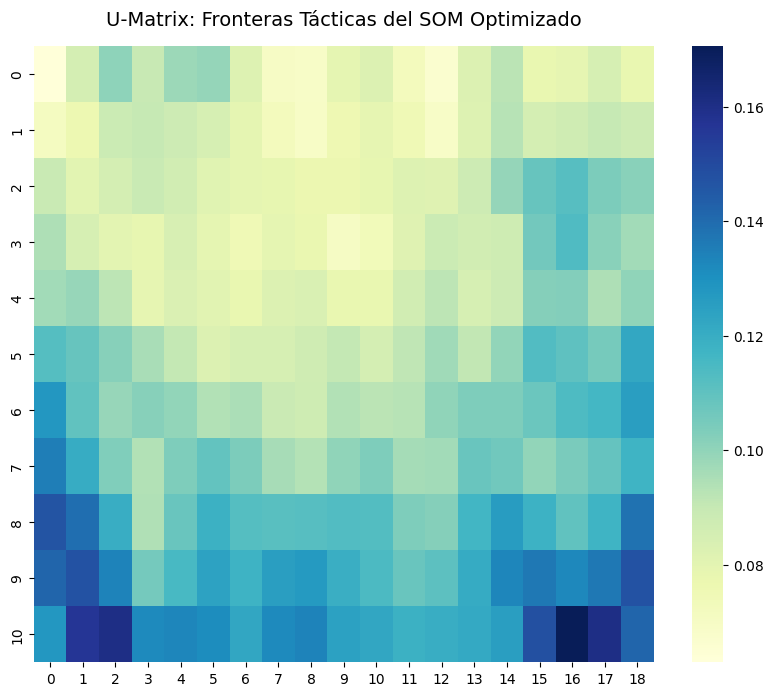

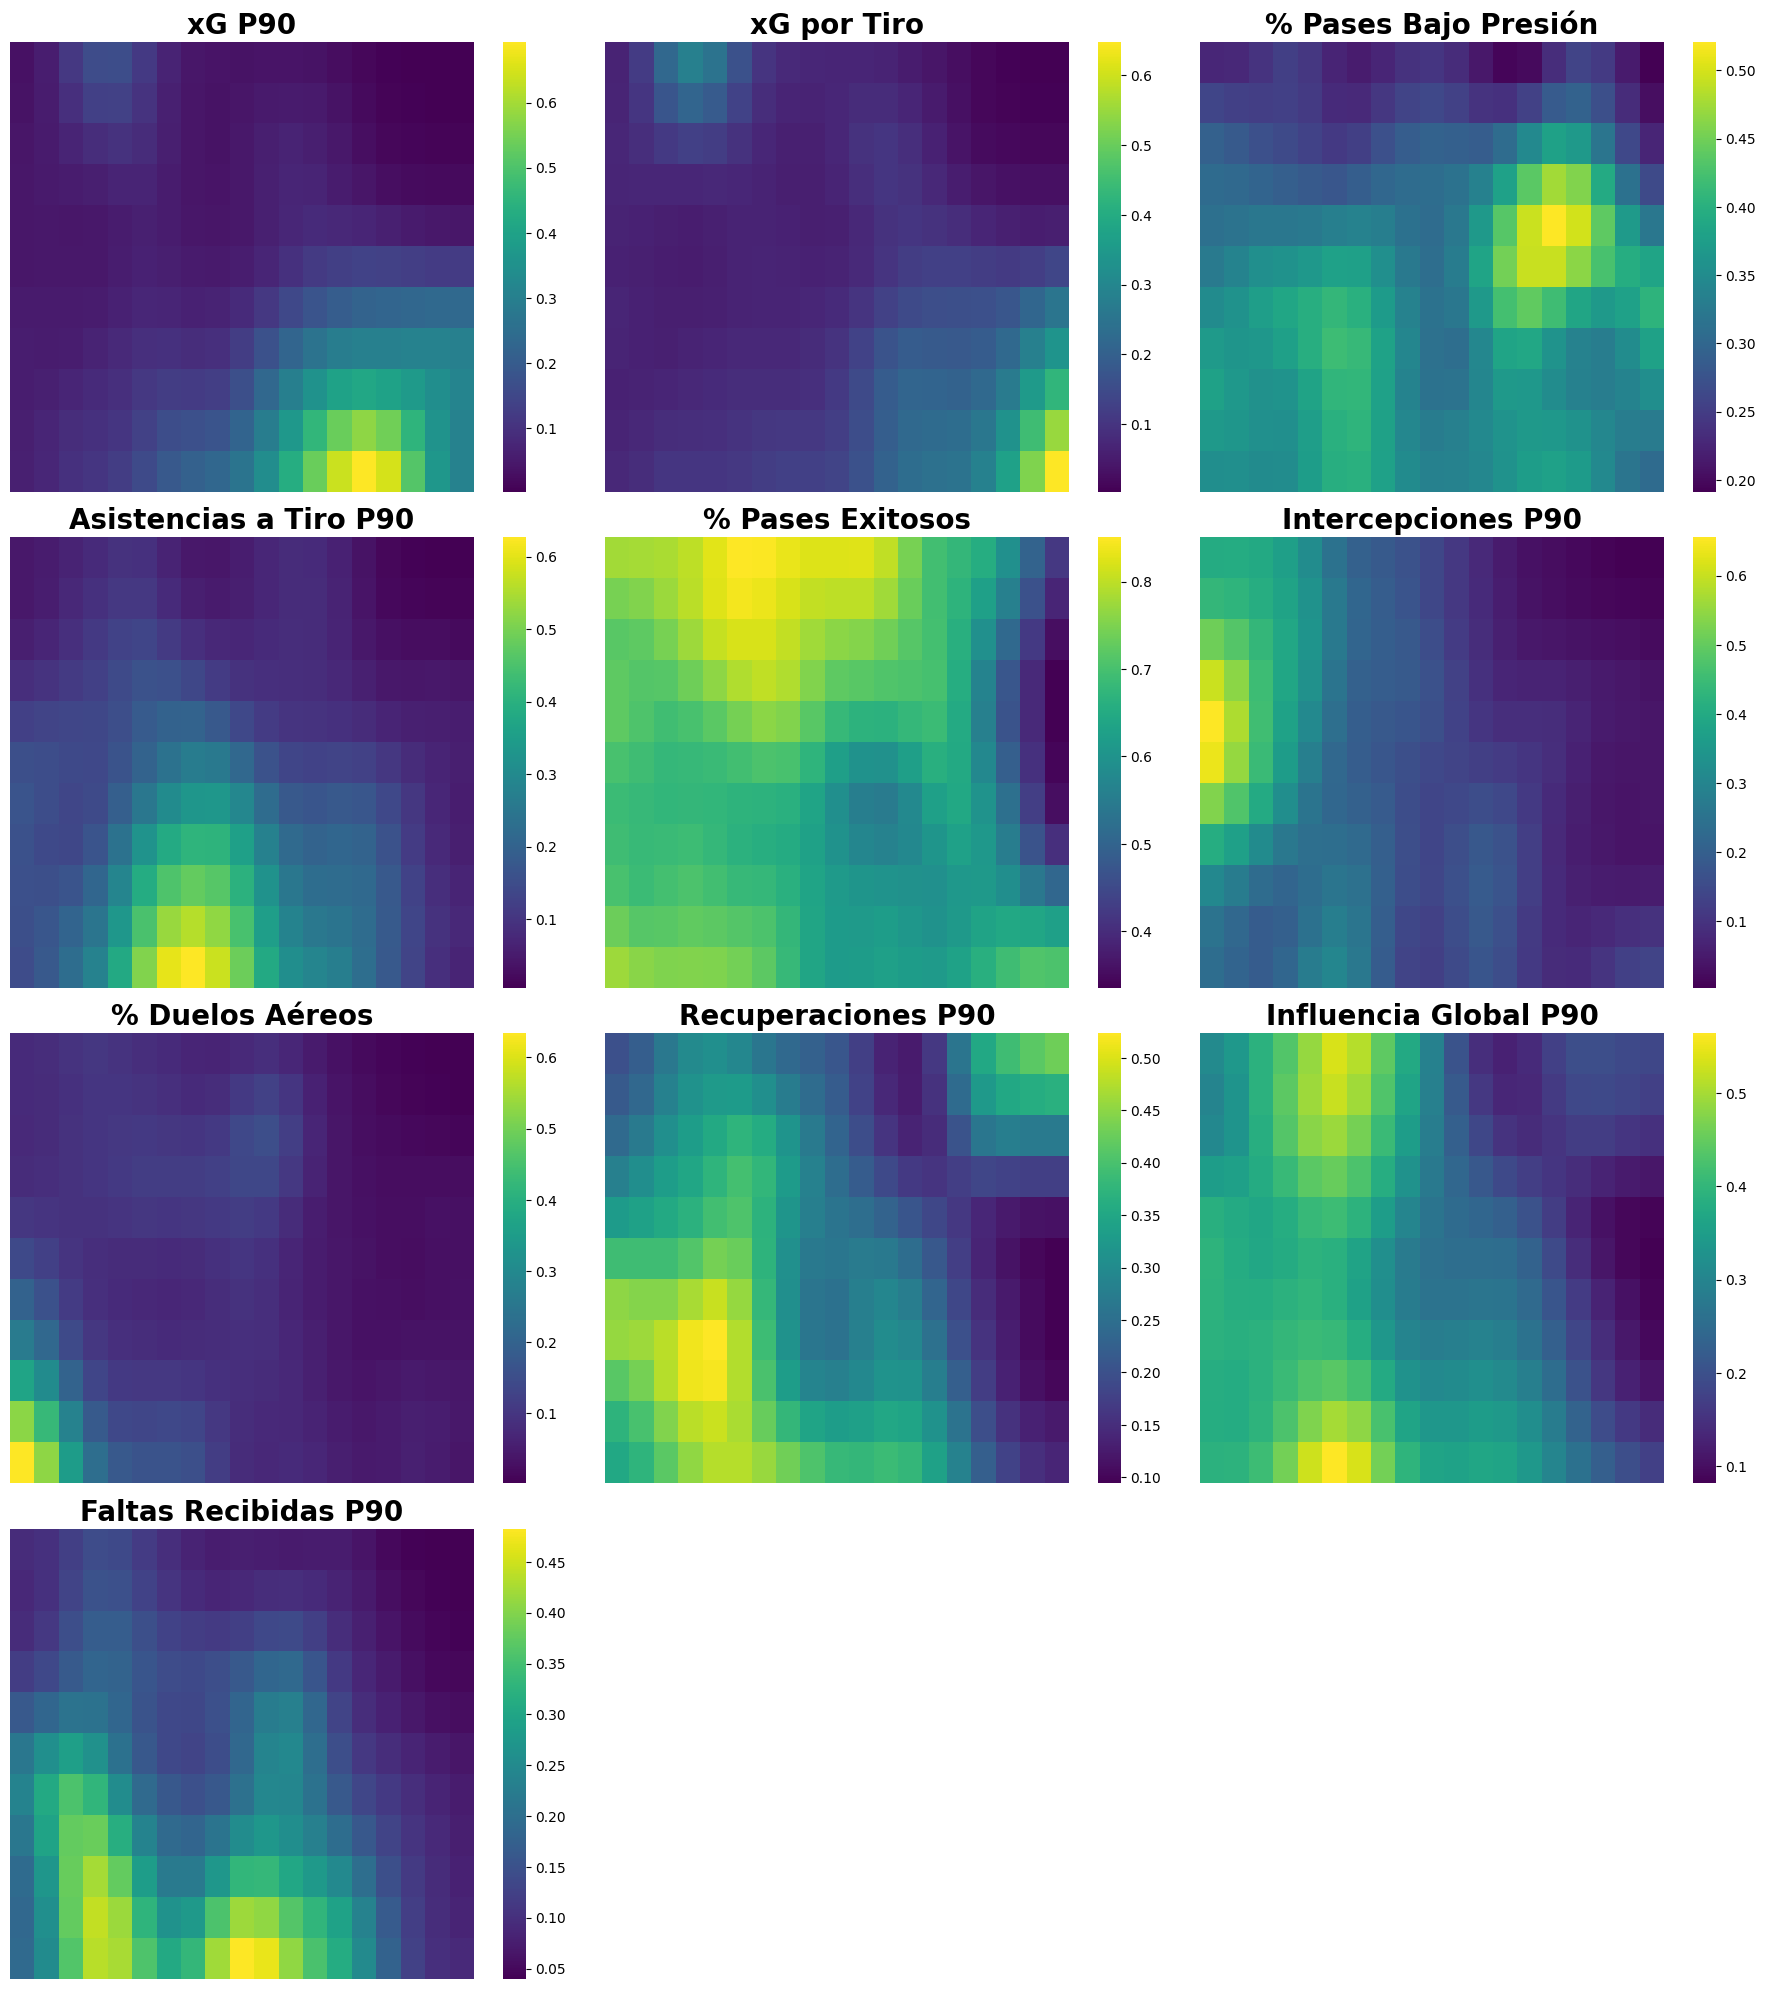

In [28]:
# ==================================================================================
# VISUALIZACIÓN DEL MAPA (U-MATRIX Y PLANOS DE COMPONENTES)
# ==================================================================================

# Definición precisa de los nombres
nombres_variables = [
    'xG P90',
    'xG por Tiro',
    '% Pases Bajo Presión',
    'Asistencias a Tiro P90',
    '% Pases Exitosos',
    'Intercepciones P90',
    '% Duelos Aéreos',
    'Recuperaciones P90',
    'Influencia Global P90',
    'Faltas Recibidas P90'
]

pesos_finales = pesos_ag
M, N, n_features = pesos_finales.shape

# 1. CÁLCULO DE LA U-MATRIX
u_matrix = np.zeros((M, N))
for i in range(M):
    for j in range(N):
        vecinos = []
        if i > 0: vecinos.append(pesos_finales[i-1, j])
        if i < M-1: vecinos.append(pesos_finales[i+1, j])
        if j > 0: vecinos.append(pesos_finales[i, j-1])
        if j < N-1: vecinos.append(pesos_finales[i, j+1])

        u_matrix[i, j] = np.mean([np.linalg.norm(pesos_finales[i, j] - v) for v in vecinos])

# 2. VISUALIZACIÓN DE LA U-MATRIX
plt.figure(figsize=(10, 8))
sns.heatmap(u_matrix, cmap='YlGnBu', annot=False)
plt.title('U-Matrix: Fronteras Tácticas del SOM Optimizado', fontsize=14, pad=15)
plt.show()

# 3. PLANOS DE COMPONENTES (Mapas de calor por variable)
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i in range(n_features):
    sns.heatmap(pesos_finales[:, :, i], ax=axes[i], cmap='viridis', cbar=True)
    axes[i].set_title(f'{nombres_variables[i]}', fontsize=20, fontweight='bold')
    axes[i].axis('off')

for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [29]:
for i, var in enumerate(feature_names):
    print(f"Neurona/Plano {i}: {var}")

Neurona/Plano 0: xG P90
Neurona/Plano 1: xG por Tiro
Neurona/Plano 2: % Pases Bajo Presión
Neurona/Plano 3: Asistencias a Tiro P90
Neurona/Plano 4: % Pases Exitosos
Neurona/Plano 5: Intercepciones P90
Neurona/Plano 6: % Duelos Aéreos
Neurona/Plano 7: Recuperaciones P90
Neurona/Plano 8: Influencia Global P90
Neurona/Plano 9: Faltas Recibidas P90


📊 Evaluando heurísticas de clustering sobre los pesos del SOM...


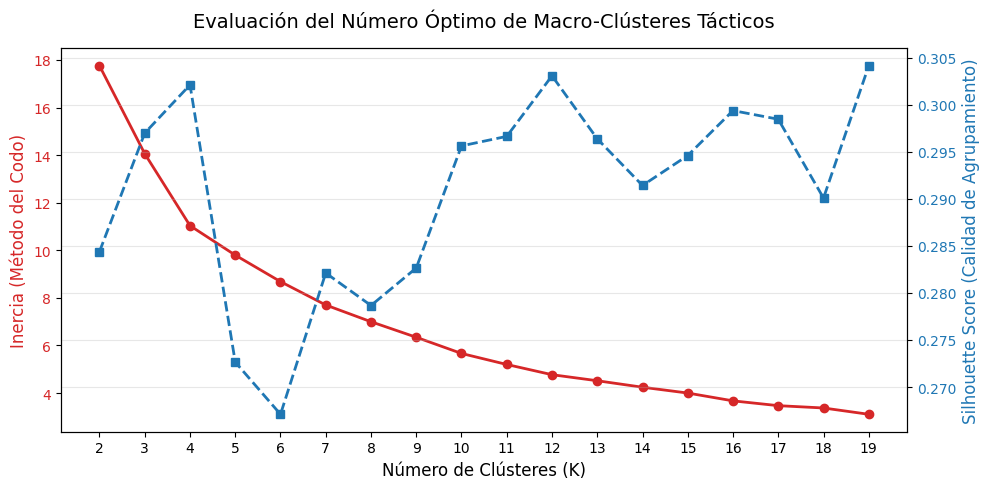

In [30]:
# ==================================================================================
#  DIAGNÓSTICO ESTADÍSTICO DEL K-ÓPTIMO (CODO Y SILUETA)
# ==================================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("📊 Evaluando heurísticas de clustering sobre los pesos del SOM...")

# Aplanamos la matriz de pesos 3D a 2D (Neuronas x Variables)
pesos_aplanados = pesos_finales.reshape(M * N, n_features)

inercia = []
silueta = []
rango_k = range(2, 20) # Probamos entre 2 y 20 clústeres macro

for k in rango_k:
    # Usamos random_state para que sea reproducible
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(pesos_aplanados)

    inercia.append(kmeans.inertia_)
    silueta.append(silhouette_score(pesos_aplanados, etiquetas))

# VISUALIZACIÓN DE LAS MÉTRICAS
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfico del Codo (Inercia) - Busca el punto donde la curva se aplana
color = 'tab:red'
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax1.set_ylabel('Inercia (Método del Codo)', color=color, fontsize=12)
ax1.plot(rango_k, inercia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Gráfico de Silueta - Busca el punto más alto
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score (Calidad de Agrupamiento)', color=color, fontsize=12)
ax2.plot(rango_k, silueta, marker='s', color=color, linewidth=2, linestyle='dashed')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluación del Número Óptimo de Macro-Clústeres Tácticos', fontsize=14, pad=15)
plt.xticks(rango_k)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

🧬 Generando 12 Macro-Clústeres Tácticos...


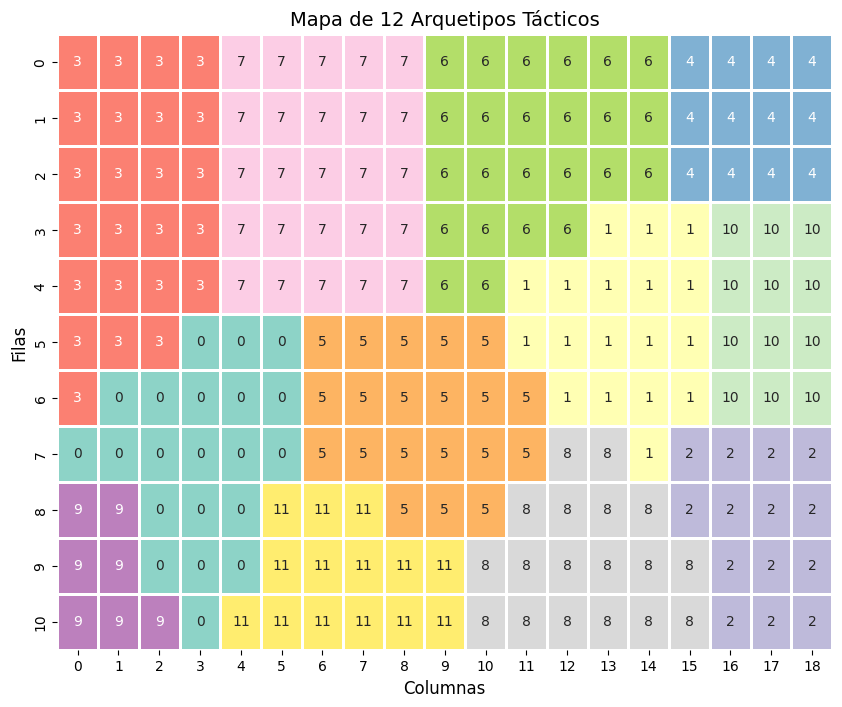


🏆 PERFILADO TÁCTICO: MACRO-DIMENSIONES Y TOP 5 JUGADORES DE ÉLITE

==================== #1 | ARQUETIPO TÁCTICO 11 ====================
🌟 IMPACTO GLOBAL DEL GRUPO: +0.35 Z-Scores promedio
📊 MACRO-PERFIL DEL CLÚSTER:
   ⚽ +0.15 | 🧠 +0.54 | 🛡️ +0.27 | 🌐 +0.41

   🔍 Desglose por Fase de Juego:
      ⚽ ATAQUE (Delanteros):
         🟢 xG P90                    : +0.19
         🟢 xG por Tiro               : +0.11
      🧠 CREACIÓN (Mediocampistas):
         🟢 % Pases Exitosos          : +0.69
         🟢 Asistencias a Tiro P90    : +0.55
         🟢 % Pases Bajo Presión      : +0.37
      🛡️ DEFENSA (Defensores):
         🟢 Recuperaciones P90        : +0.44
         🟢 Intercepciones P90        : +0.23
         🟢 % Duelos Aéreos           : +0.14
      🌐 GLOBAL (Otras):
         🟢 Influencia Global P90     : +0.48
         🟢 Faltas Recibidas P90      : +0.34

   ⭐ Top 5 Jugadores (Máximo Rendimiento Estadístico del Grupo):
      🏃 Carlos Alberto Vela Garrido | Score Promedio: +0.54
      🏃 Neyma

In [31]:
# ==================================================================================
# CLUSTERING DEFINITIVO, PERFILADO DIMENSIONAL Y JUGADORES ÉLITE
# ==================================================================================


# 1. DEFINICIÓN DEL DICCIONARIO DE VARIABLES
nombres_variables = [
    'xG P90',
    'xG por Tiro',
    '% Pases Bajo Presión',
    'Asistencias a Tiro P90',
    '% Pases Exitosos',
    'Intercepciones P90',
    '% Duelos Aéreos',
    'Recuperaciones P90',
    'Influencia Global P90',
    'Faltas Recibidas P90'
]

# 2. DEFINICIÓN DE DIMENSIONES (Criterio de Experto Actualizado)
dimensiones_tacticas = {
    '⚽ ATAQUE (Delanteros)': ['xG P90', 'xG por Tiro'],
    '🧠 CREACIÓN (Mediocampistas)': ['% Pases Bajo Presión', 'Asistencias a Tiro P90', '% Pases Exitosos'],
    '🛡️ DEFENSA (Defensores)': ['Intercepciones P90', '% Duelos Aéreos', 'Recuperaciones P90'],
    '🌐 GLOBAL (Otras)': ['Influencia Global P90', 'Faltas Recibidas P90']
}

# 🚨 AJUSTA ESTE VALOR según lo que te dijo el gráfico del Codo/Silueta
K_OPTIMO = 12

print(f"🧬 Generando {K_OPTIMO} Macro-Clústeres Tácticos...")

# 3. Agrupamos las neuronas usando K-Means
kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20)
etiquetas_neuronas = kmeans_final.fit_predict(pesos_aplanados)
cluster_mapa = etiquetas_neuronas.reshape(M, N)

# 4. Visualizamos el Mapa de Clústeres
plt.figure(figsize=(10, 8))
sns.heatmap(cluster_mapa, cmap='Set3', linewidths=1, linecolor='white', annot=True, cbar=False)
plt.title(f'Mapa de {K_OPTIMO} Arquetipos Tácticos', fontsize=14)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)
plt.show()

# 5. ASIGNAMOS CADA JUGADOR A SU CLÚSTER Y CALCULAMOS SU IMPACTO INDIVIDUAL
etiquetas_jugadores = []
for jugador in datos_entrenamiento:
    dists = np.sum((pesos_finales - jugador)**2, axis=2)
    bmu = np.unravel_index(np.argmin(dists), (M, N))
    etiquetas_jugadores.append(cluster_mapa[bmu[0], bmu[1]])

df_resultados = pd.DataFrame(datos_entrenamiento, columns=nombres_variables)
df_resultados['Arquetipo_SOM'] = etiquetas_jugadores

# Calculamos el promedio INDIVIDUAL de cada jugador a través de todas las variables
impacto_individual = df_resultados[nombres_variables].mean(axis=1)

# Agrupamos y calculamos la media de cada variable por clúster (Para los perfiles)
perfiles_descriptivos = df_resultados.groupby('Arquetipo_SOM').mean()
perfiles_descriptivos['Impacto_Total_Cluster'] = perfiles_descriptivos.mean(axis=1)

# 6. IDENTIFICACIÓN DIMENSIONAL Y RANKING DE JUGADORES ÉLITE
print("\n" + "="*85)
print("🏆 PERFILADO TÁCTICO: MACRO-DIMENSIONES Y TOP 5 JUGADORES DE ÉLITE")
print("="*85)

try:
    df_nombres = perfiles_multi.copy()
    df_nombres['Arquetipo_SOM'] = etiquetas_jugadores
    # Le inyectamos el score de impacto calculado matemáticamente a cada jugador real
    df_nombres['Score_Jugador'] = impacto_individual.values

    # Ordenamos los IDs de los clústeres desde el de mayor Impacto Total al menor
    clusters_ordenados = perfiles_descriptivos.sort_values(by='Impacto_Total_Cluster', ascending=False).index

    for ranking_pos, cluster_id in enumerate(clusters_ordenados, start=1):
        medias_cluster = perfiles_descriptivos.loc[cluster_id]
        score_impacto_cluster = medias_cluster['Impacto_Total_Cluster']

        print(f"\n==================== #{ranking_pos} | ARQUETIPO TÁCTICO {cluster_id} ====================")
        print(f"🌟 IMPACTO GLOBAL DEL GRUPO: {score_impacto_cluster:+.2f} Z-Scores promedio")

        # --- CÁLCULO DE SCORES MACRO-DIMENSIONALES ---
        scores_dimensiones = {}
        for dim_nombre, vars_en_dim in dimensiones_tacticas.items():
            score_promedio = medias_cluster[vars_en_dim].mean()
            scores_dimensiones[dim_nombre] = score_promedio

        print("📊 MACRO-PERFIL DEL CLÚSTER:")
        resumen_macro = " | ".join([f"{dim.split(' ')[0]} {score:+.2f}" for dim, score in scores_dimensiones.items()])
        print(f"   {resumen_macro}\n")

        # --- DESGLOSE VARIABLE POR VARIABLE ---
        print("   🔍 Desglose por Fase de Juego:")
        for dim_nombre, vars_en_dim in dimensiones_tacticas.items():
            print(f"      {dim_nombre}:")
            valores_dim = medias_cluster[vars_en_dim].sort_values(ascending=False)
            for var_name, valor_z in valores_dim.items():
                indicador = "🟢" if valor_z > 0 else "🔴"
                print(f"         {indicador} {var_name:<25} : {valor_z:+.2f}")

        # --- NUEVA LÓGICA: TOP 5 JUGADORES POR SCORE INDIVIDUAL ---
        print("\n   ⭐ Top 5 Jugadores (Máximo Rendimiento Estadístico del Grupo):")
        jugadores_cluster = df_nombres[df_nombres['Arquetipo_SOM'] == cluster_id]

        # Ahora ordenamos por el Score del Jugador en lugar de los minutos
        top_5 = jugadores_cluster.sort_values(by='Score_Jugador', ascending=False).head(5)

        for index, row in top_5.iterrows():
            nombre = row['player']
            score_individual = row['Score_Jugador']
            print(f"      🏃 {nombre:<25} | Score Promedio: {score_individual:+.2f}")
        print("-" * 85)

except NameError:
    print("\n[!] Error: No se encontró 'perfiles_multi'. Asegúrate de que el DataFrame base exista.")

In [32]:
# ==================================================================================
# BLOQUE 7 DEFINITIVO: CONSTRUCCIÓN DEL DATASET MAESTRO ENRIQUECIDO (CAPA GOLD)
# ==================================================================================


print("\n" + "="*85)
print("💾 CONSTRUYENDO Y EXPORTANDO DATASET MAESTRO PARA STORYTELLING")
print("="*85)

# 1. INICIALIZAMOS EL DATAFRAME MAESTRO
# df_nombres ya contiene: player, Arquetipo_SOM, Score_Jugador y metadata
df_maestro = df_nombres.copy()

# 2. RESCATE DE METADATA CATEGÓRICA Y DE CONTEXTO
try:
    # Renombramos 'position' a 'type' según requerimiento de usuario
    df_maestro['type'] = perfiles_multi['position'].values
    df_maestro['Minutos_Jugados'] = perfiles_multi['minutos_jugados'].values
except KeyError as e:
    print(f"⚠️ Aviso: La columna {e} no se encontró. Revisa los nombres en perfiles_multi.")

# 3. INYECCIÓN DE VARIABLES TÁCTICAS: CRUDAS, MIN-MAX (Escaladas) Y PERCENTILES
for var in nombres_variables:
    # A. Variable Cruda (Valores originales P90 o %)
    df_maestro[f'{var}_Crudo'] = perfiles_multi[var].values

    # B. Variable MinMax (Los valores 0-1 usados en el SOM)
    # Nota: Se corrige de 'ZScore' a 'MinMax' por precisión técnica
    df_maestro[f'{var}_MinMax'] = df_resultados[var].values

    # C. Variable Percentil (0 a 100)
    df_maestro[f'{var}_Percentil'] = df_resultados[var].rank(pct=True) * 100

# 4. EXPORTACIÓN FINAL
archivo_salida = "Master_Dataset_Scouting.csv"
df_maestro.to_csv(archivo_salida, index=False, encoding='utf-8-sig')

tamano_kb = os.path.getsize(archivo_salida) / 1024
print(f"\n✅ ¡Dataset Maestro consolidado y exportado con éxito!")
print(f"📊 Dimensiones finales: {df_maestro.shape[0]} jugadores x {df_maestro.shape[1]} variables.")
print(f"⚖️ Peso del archivo: {tamano_kb:.2f} KB")
print("\n📥 Iniciando descarga automática...")
files.download(archivo_salida)


💾 CONSTRUYENDO Y EXPORTANDO DATASET MAESTRO PARA STORYTELLING

✅ ¡Dataset Maestro consolidado y exportado con éxito!
📊 Dimensiones finales: 1288 jugadores x 62 variables.
⚖️ Peso del archivo: 932.88 KB

📥 Iniciando descarga automática...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>